In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (5634, 30)
Test set: (1409, 30)


In [3]:
#Baseline Model - Logistic Regression
lr  = LogisticRegression(random_state=0)
lr.fit(X_train, y_train)

#Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print(f"Accuracy:{accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassifcation Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy:0.8013
AUC: 0.8516

Classifcation Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [4]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7956
AUC: 0.8303

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [5]:
#Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=0)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.8027
AUC: 0.8517

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



              Model  Accuracy      AUC
Logistic Regression  0.801278 0.851559
      Random Forest  0.795600 0.830337
  Gradient Boosting  0.802697 0.851746


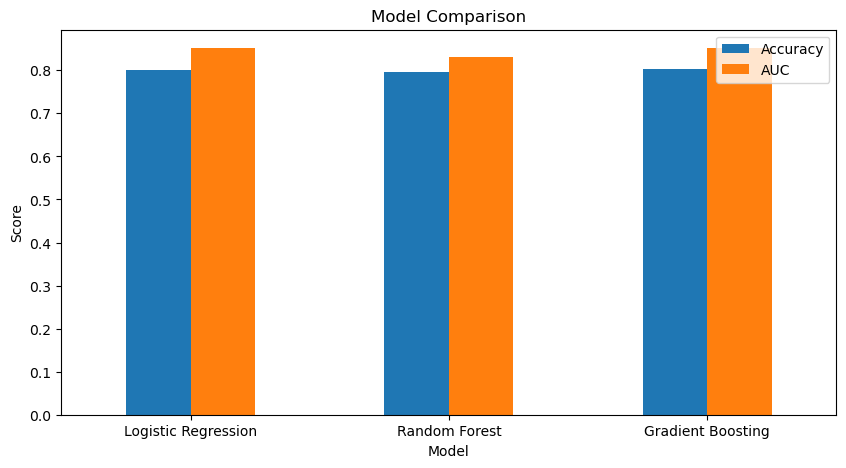

In [6]:
#Model Comparison
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

results_df.plot(x='Model', y=['Accuracy', 'AUC'], kind='bar', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler.fit(X_train[num_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [8]:
#Save best model (Gradient Boosting)
joblib.dump(gb, '../data/best_model.pkl')
joblib.dump(scaler, '../data/scaler.pkl')

print("Model: Gradien Boosting")
print(f"AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")

Model: Gradien Boosting
AUC: 0.8517


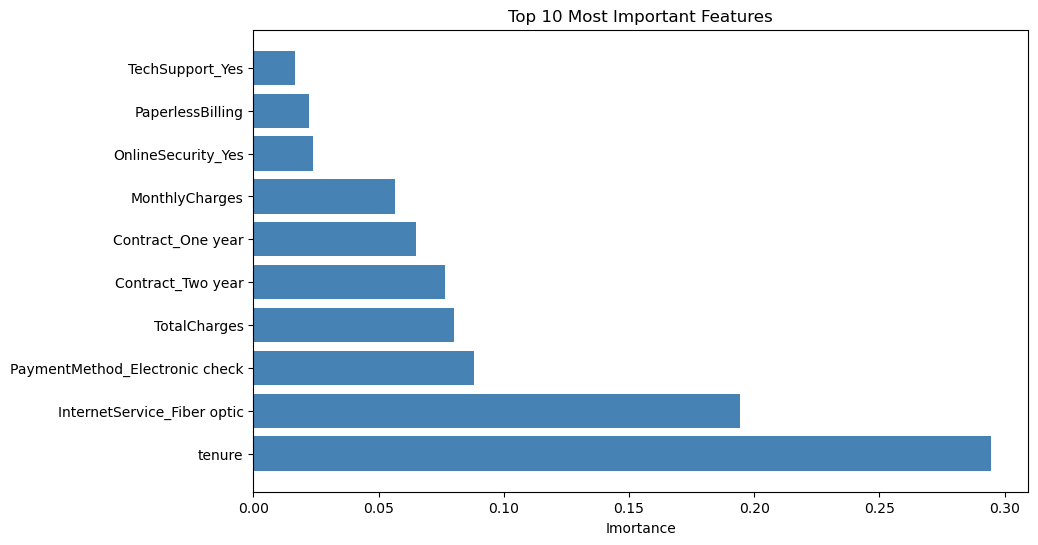

                       Feature  Importance
                        tenure    0.294722
   InternetService_Fiber optic    0.194416
PaymentMethod_Electronic check    0.087941
                  TotalCharges    0.080070
             Contract_Two year    0.076460
             Contract_One year    0.064912
                MonthlyCharges    0.056714
            OnlineSecurity_Yes    0.023669
              PaperlessBilling    0.022042
               TechSupport_Yes    0.016674


In [ ]:
#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.title('Top 10 Most Important Features')
plt.xlabel('Imortance')
plt.gca().invert_yaxis
plt.show()

print(feature_importance.to_string(index=False))

In [ ]:
print("=== Training Summary ===")
print(f"\nBest Model: Gradient Boosting")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"\nTop 3 Most Important Features:")
print(f"1. tenure (how long customer stays)")
print(f"2. InternetService_Fiber optic")
print(f"3. PaymentMethod_Electronic check")
print(f"\nModel saved to: ../data/best_model.pkl")

=== Training Summary ===

Best Model: Gradient Boosting
Accuracy: 0.8027
AUC: 0.8517

Top 3 Most Important Features:
1. tenure (how long customer stays)
2. InternetService_Fiber optic
3. PaymentMethod_Electronic check

Model saved to: ../data/best_model.pkl
